# Music / Billboard Final Poster Analysis Notebook

# Billboard Hot 100 Analysis

## Setup + Data Read-In

In [30]:
# ============================================================
# Music / Billboard Final Poster Analysis Notebook
# Setup + Data Read-In
# ============================================================

# Core data libraries
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# Machine learning / clustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Statistical tests
from scipy.stats import mannwhitneyu, chi2_contingency

# Optional display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# ============================================================
# Read in data
# ============================================================

# Full Billboard Hot 100 weekly dataset
df_billboard = pd.read_csv("hot100.csv")

# Final matched Top 40 / audio-feature dataset
# Use the FULL_BACKUP version because it keeps matched_song,
# matched_artist, match scores, genre families, and audio features.
audio_df_raw = pd.read_csv("final_df_FULL_BACKUP.csv")

# Quick shape checks
print("Billboard weekly rows:", df_billboard.shape)
print("Audio dataset rows:", audio_df_raw.shape)

display(df_billboard.head())
display(audio_df_raw.head())

Billboard weekly rows: (353558, 8)
Audio dataset rows: (4078, 84)


,Date,Song,Artist,Rank,Last Week,Peak Position,Weeks in Charts,Image URL
0,1958-07-30,Poor Little Fool,Ricky Nelson,1,-,1,1,NaN
1,1958-07-30,Patricia,Perez Prado And His Orchestra,2,-,2,1,NaN
2,1958-07-30,Splish Splash,Bobby Darin,3,-,3,1,NaN
3,1958-07-30,Hard Headed Woman,Elvis Presley With The Jordanaires,4,-,4,1,https://charts-static.billboard.com/img/1958/0...
4,1958-07-30,When,Kalin Twins,5,-,5,1,NaN


,Song,Artist,first_chart_date,last_chart_date,entry_rank,peak_rank,total_weeks,top10_weeks,top40_weeks,avg_rank,image_url,peak_date,lifespan_weeks,time_to_peak,entry_year,weeks_since_last_chart,potentially_incomplete,search_song,search_artist,search_term,matched_song,matched_artist,collection,preview_url,apple_release_date,apple_track_time_ms,apple_duration_sec,apple_genre,apple_collection,apple_track_id,apple_artist_id,match_score,title_score,artist_score,version_penalty,match_status,failure_reason,artist_overlap,usable_match,usable_match_v2,recovery_reason,preview_filename,preview_duration_sec,tempo_bpm,beat_confidence,rms_loudness,mode,key_strength,spectral_centroid_mean,spectral_rolloff_mean,valence,arousal,genre_1,genre_1_score,genre_2,genre_2_score,genre_3,genre_3_score,genre_4,genre_4_score,genre_5,genre_5_score,genre_family_blues,genre_family_brass_and_military,genre_family_children_s,genre_family_classical,genre_family_electronic,genre_family_folk_world_and_country,genre_family_funk_soul,genre_family_hip_hop,genre_family_jazz,genre_family_latin,genre_family_non_music,genre_family_pop,genre_family_reggae,genre_family_rock,genre_family_stage_and_screen,audio_feature_error,preview_file,tempo_bpm_raw,tempo_bpm_adjusted,tempo_adjustment_reason,days_release_to_chart,days_release_to_peak
0,"""1 Step Forward, 3 Steps Back""",Olivia Rodrigo,2021-06-02,2021-06-23,19,19,4,0,2,54.250000,https://charts-static.billboard.com/img/2019/1...,2021-06-02,4,0.0,2021,256.0,False,"""1 Step Forward, 3 Steps Back""",Olivia Rodrigo,1 step forward 3 steps back olivia rodrigo,"1 step forward, 3 steps back",Olivia Rodrigo,SOUR,https://audio-ssl.itunes.apple.com/itunes-asse...,2021-05-21 12:00:00,163593.0,163.593,Pop,SOUR,1.560736e+09,979458609.0,1.00,1.0,1.000000,0.0,AUTO_ACCEPT,SUCCESS,1.0,True,True,NaN,preview_clips/olivia_rodrigo__1_step_forward_3...,29.97551,172.265625,0.554861,0.185166,major,0.882782,1722.536017,776.578637,4.464632,4.418778,Pop---Ballad,0.143656,"Folk, World, & Country---Fado",0.106863,Pop---K-pop,0.103916,Electronic---Tropical House,0.076878,Funk / Soul---Neo Soul,0.061464,0.010976,0.000059,0.019153,0.011089,0.511586,0.215863,0.155670,0.042945,0.100163,0.052241,0.014486,0.448652,0.005238,0.152280,0.011177,NaN,preview_clips/olivia_rodrigo__1_step_forward_3...,172.265625,86.132812,halved_145_180_likely_double_time,11.0,11.0
1,"""1, 2 Step""",Ciara Featuring Missy Elliott,2005-01-05,2005-07-20,2,2,39,12,24,19.448276,https://charts-static.billboard.com/img/2004/0...,2005-01-05,39,0.0,2005,1087.0,False,"""1, 2 Step""",Ciara Featuring Missy Elliott,1 2 step ciara,"1, 2 Step (feat. Missy Elliott) [Mixed]",Ciara,Fool's Gold Radio: Miles Medina (DJ Mix),https://audio-ssl.itunes.apple.com/itunes-asse...,2023-03-10 12:00:00,84901.0,84.901,Hip-Hop/Rap,Fool's Gold Radio: Miles Medina (DJ Mix),1.674065e+09,14317116.0,1.00,1.0,1.000000,0.0,AUTO_ACCEPT,SUCCESS,1.0,True,True,NaN,preview_clips/ciara_featuring_missy_elliott__1...,29.92907,116.173401,2.469709,0.274486,major,0.508867,3324.488946,2381.004724,7.023382,5.322175,Hip Hop---Trap,0.255818,Electronic---House,0.080486,Hip Hop---Cloud Rap,0.074280,Funk / Soul---Contemporary R&B,0.066612,Electronic---Bassline,0.065759,0.000283,0.000062,0.000036,0.000017,0.811289,0.001637,0.123932,0.497635,0.000735,0.010825,0.000528,0.070866,0.003168,0.007899,0.000968,NaN,preview_clips/ciara_featuring_missy_elliott__1...,116.173401,116.173401,unchanged,-6639.0,-6639.0
2,"""1, 2, 3, 4""",Plain White T's,2009-02-04,2009-06-17,91,34,20,0,5,47.800000,https://charts-static.billboard.com/img/2005/1...,2009-05-20,20,15.0,2009,883.0,False,"""1, 2, 3, 4""",Plain White T's,1 2 3 4 plain white ts,"1, 2, 3, 4",Plain White T's,Valentine's Day 2022,https://audio-ssl.itunes.apple.com/itunes-asse...,2008-09-23 12:00:00,198360.0,198.360,Rock,Valentine's Day 2022,1.605885e+09,16252710.0,1.00,1.0,1.000000,0.0,AUTO_ACCEPT,SUCCESS,1.0,True,True,NaN,preview_clips/plain_white_t_s__1_2_3_4__160588...,29.97551,89.632843,2.634862,0

In [2]:
# ============================================================
# Clean date columns
# ============================================================

# Billboard weekly chart date
df_billboard["Date"] = pd.to_datetime(
    df_billboard["Date"],
    errors="coerce"
)

# Audio / Apple date columns
date_cols = [
    "first_chart_date",
    "last_chart_date",
    "peak_date",
    "apple_release_date"
]

for col in date_cols:
    if col in audio_df_raw.columns:
        audio_df_raw[col] = pd.to_datetime(
            audio_df_raw[col],
            errors="coerce"
        )

# Confirm date ranges
print("Billboard date range:")
print(df_billboard["Date"].min(), "to", df_billboard["Date"].max())

print("\nAudio date range:")
print(audio_df_raw["first_chart_date"].min(), "to", audio_df_raw["first_chart_date"].max())

Billboard date range:
1958-07-30 00:00:00 to 2026-05-20 00:00:00

Audio date range:
2005-01-05 00:00:00 to 2026-05-13 00:00:00


In [3]:
# ============================================================
# Build song-level Billboard lifecycle dataset
# ============================================================

# Keep project time frame
df_billboard = df_billboard[
    df_billboard["Date"].dt.year >= 2005
].copy()

latest_date = df_billboard["Date"].max()

# Collapse weekly chart rows into one row per Song + Artist
song_life = (
    df_billboard
    .sort_values("Date")
    .groupby(["Song", "Artist"])
    .agg(
        first_chart_date=("Date", "min"),
        last_chart_date=("Date", "max"),
        entry_rank=("Rank", "first"),
        peak_rank=("Rank", "min"),
        total_weeks=("Weeks in Charts", "max"),
        top10_weeks=("Rank", lambda x: (x <= 10).sum()),
        top40_weeks=("Rank", lambda x: (x <= 40).sum()),
        avg_rank=("Rank", "mean"),
        image_url=("Image URL", "first")
    )
    .reset_index()
)

# Find peak date
peak_dates = (
    df_billboard.loc[
        df_billboard.groupby(["Song", "Artist"])["Rank"].idxmin(),
        ["Song", "Artist", "Date"]
    ]
    .rename(columns={"Date": "peak_date"})
)

song_life = song_life.merge(
    peak_dates,
    on=["Song", "Artist"],
    how="left"
)

# Lifecycle metrics
song_life["lifespan_weeks"] = song_life["total_weeks"]

song_life["time_to_peak"] = (
    (song_life["peak_date"] - song_life["first_chart_date"]).dt.days / 7
)

song_life["entry_year"] = song_life["first_chart_date"].dt.year

song_life["weeks_since_last_chart"] = (
    (latest_date - song_life["last_chart_date"]).dt.days / 7
)

song_life["potentially_incomplete"] = (
    song_life["weeks_since_last_chart"] < 4
)

# Era label
song_life["era"] = np.where(
    song_life["entry_year"] < 2018,
    "Pre TikTok",
    "Post TikTok"
)

# Completed chart runs only
song_life_completed = song_life[
    ~song_life["potentially_incomplete"]
].copy()

# Top 10 success flag
song_life_completed["reached_top10"] = (
    song_life_completed["peak_rank"] <= 10
)

print("Song-level Billboard dataset:", song_life.shape)
print("Completed songs only:", song_life_completed.shape)

display(song_life_completed.head())

Song-level Billboard dataset: (10505, 18)
Completed songs only: (10363, 19)


,Song,Artist,first_chart_date,last_chart_date,entry_rank,peak_rank,total_weeks,top10_weeks,top40_weeks,avg_rank,image_url,peak_date,lifespan_weeks,time_to_peak,entry_year,weeks_since_last_chart,potentially_incomplete,era,reached_top10
0,"""1 Step Forward, 3 Steps Back""",Olivia Rodrigo,2021-06-02,2021-06-23,19,19,4,0,2,54.250000,https://charts-static.billboard.com/img/2019/1...,2021-06-02,4,0.0,2021,256.0,False,Post TikTok,False
1,"""1, 2 Many""",Luke Combs & Brooks & Dunn,2019-09-25,2019-09-25,97,97,1,0,0,97.000000,https://charts-static.billboard.com/img/2015/0...,2019-09-25,1,0.0,2019,347.0,False,Post TikTok,False
2,"""1, 2 Step""",Ciara Featuring Missy Elliott,2005-01-05,2005-07-20,2,2,39,12,24,19.448276,https://charts-static.billboard.com/img/2004/0...,2005-01-05,39,0.0,2005,1087.0,False,Pre TikTok,True
3,"""1, 2, 3, 4""",Plain White T's,2009-02-04,2009-06-17,91,34,20,0,5,47.800000,https://charts-static.billboard.com/img/2005/1...,2009-05-20,20,15.0,2009,883.0,False,Pre TikTok,False
4,"""10,000 Hours""",Dan + Shay & Justin Bieber,2019-10-16,2020-05-06,4,4,30,14,28,15.933333,https://charts-static.billboard.com/img/2019/1...,2019-10-16,30,0.0,2019,315.0,False,Post TikTok,True


In [4]:
# ============================================================
# Prepare audio dataframe
# ============================================================

audio_df = audio_df_raw.copy()

# Era labels
audio_df["entry_year"] = pd.to_datetime(
    audio_df["first_chart_date"],
    errors="coerce"
).dt.year

audio_df["audio_era"] = np.where(
    audio_df["entry_year"] < 2018,
    "Pre TikTok",
    "Post TikTok"
)

# Optional release year
audio_df["release_year"] = pd.to_datetime(
    audio_df["apple_release_date"],
    errors="coerce"
).dt.year

# Audio features used for clustering
audio_features = [
    "valence",
    "arousal",
    "rms_loudness",
    "spectral_centroid_mean",
    "tempo_bpm_adjusted"
]

# Drop rows missing audio features
audio_df = audio_df.dropna(subset=audio_features).copy()

print("Clean audio dataset:", audio_df.shape)
display(audio_df[audio_features + ["audio_era"]].head())

Clean audio dataset: (3783, 86)


,valence,arousal,rms_loudness,spectral_centroid_mean,tempo_bpm_adjusted,audio_era
0,4.464632,4.418778,0.185166,1722.536017,86.132812,Post TikTok
1,7.023382,5.322175,0.274486,3324.488946,116.173401,Pre TikTok
2,5.436965,5.027247,0.260873,2826.144464,89.632843,Pre TikTok
3,4.820089,5.673097,0.247301,3112.863702,178.205811,Post TikTok
4,6.257137,5.357296,0.248761,2545.897491,112.451279,Pre TikTok


In [5]:
# ============================================================
# Audio feature clustering + PCA visualization coordinates
# ============================================================

# Standardize audio features
X_audio = audio_df[audio_features]
X_audio_scaled = StandardScaler().fit_transform(X_audio)

# KMeans clustering
audio_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

audio_df["audio_cluster"] = audio_kmeans.fit_predict(X_audio_scaled)

# PCA for visualization only
audio_pca = PCA(n_components=2)
audio_pcs = audio_pca.fit_transform(X_audio_scaled)

audio_df["audio_PC1"] = audio_pcs[:, 0]
audio_df["audio_PC2"] = audio_pcs[:, 1]

# Cluster labels
cluster_labels = {
    0: "Energetic Crossover",
    1: "Hip-Hop Dominant",
    2: "Mellow / Alternative"
}

audio_df["audio_cluster_label"] = (
    audio_df["audio_cluster"].map(cluster_labels)
)

# PCA explained variance
print("Audio PCA explained variance:")
print(audio_pca.explained_variance_ratio_)
print("Total explained:", audio_pca.explained_variance_ratio_.sum())

# Cluster counts
display(audio_df["audio_cluster_label"].value_counts())

Audio PCA explained variance:
[0.42431507 0.20190709]
Total explained: 0.6262221555859305


audio_cluster_label
Energetic Crossover     1748
Hip-Hop Dominant        1351
Mellow / Alternative     684
Name: count, dtype: int64

## Billboard figures

### Median lifespan LOADED ✅

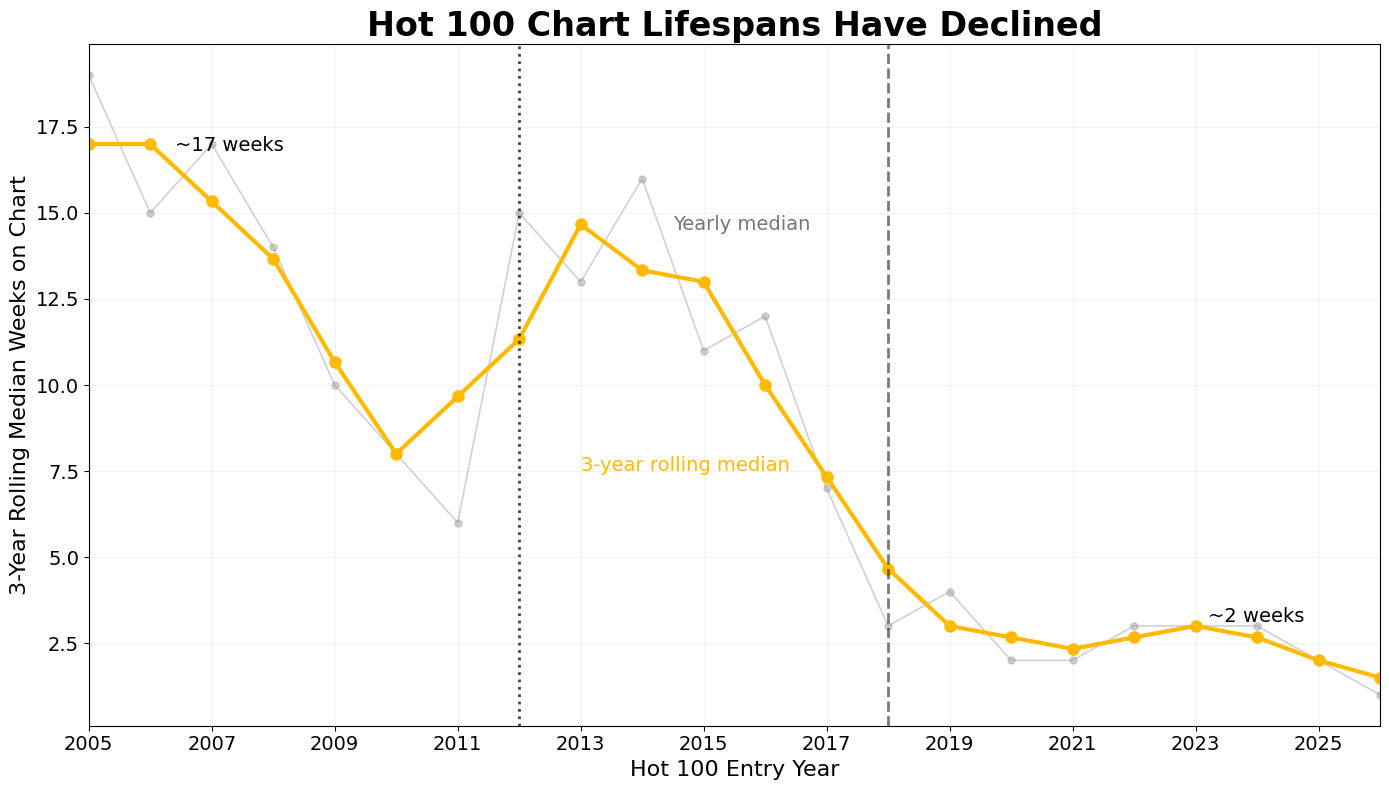

In [86]:
# ============================================================
# Billboard Lifespan Trend (Final Poster Version)
# ============================================================

import matplotlib.pyplot as plt

median_lifespan_all = (
    song_life
    .groupby("entry_year")["lifespan_weeks"]
    .median()
)

median_lifespan_completed = (
    song_life_completed
    .groupby("entry_year")["lifespan_weeks"]
    .median()
)

# ------------------------------------------------------------
# 3-year rolling median
# ------------------------------------------------------------
median_lifespan_completed_roll = (
    median_lifespan_completed
    .rolling(
        window=3,
        center=True,
        min_periods=1
    )
    .mean()
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))

# Raw yearly median in background
ax.plot(
    median_lifespan_completed.index,
    median_lifespan_completed.values,
    marker="o",
    markersize=5,
    linewidth=1.2,
    color="#999999",
    alpha=0.45,
    label="Yearly median"
)

# Rolling median as main trend
ax.plot(
    median_lifespan_completed_roll.index,
    median_lifespan_completed_roll.values,
    marker="o",
    markersize=8,
    linewidth=3,
    color="#ffba00",
    label="3-year rolling median"
)
# ------------------------------------------------------------
# Era milestone lines
# ------------------------------------------------------------
ax.axvline(
    x=2012,
    linestyle=":",
    linewidth=2.0,
    color="#222222",
    alpha=0.85
)

ax.axvline(
    x=2018,
    linestyle="--",
    linewidth=2.0,
    color="#222222",
    alpha=0.60
)

# ------------------------------------------------------------
# Endpoint annotations
# ------------------------------------------------------------
ax.text(
    2006.4,
    16.8,
    "~17 weeks",
    fontsize=14
)

ax.text(
    2023.2,
    3.1,
    "~2 weeks",
    fontsize=14
)

# ------------------------------------------------------------
# Labels and title
# ------------------------------------------------------------
ax.set_title(
    "Hot 100 Chart Lifespans Have Declined",
    fontsize=24,
    fontweight="bold"
)

ax.set_xlabel(
    "Hot 100 Entry Year",
    fontsize=16
)

ax.set_ylabel(
    "3-Year Rolling Median Weeks on Chart",
    fontsize=16
)

ax.set_xticks(range(2005, 2026, 2))
ax.set_xlim(2005, 2026)

ax.tick_params(
    axis="both",
    labelsize=14
)

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------
ax.text(
    2013,
    7.5,
    "3-year rolling median",
    color="#ffba00",
    fontsize=14
)

ax.text(
    2014.5,
    14.5,
    "Yearly median",
    color="#777777",
    fontsize=14
)

# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------
ax.grid(
    True,
    alpha=0.15
)

fig.tight_layout()

# ------------------------------------------------------------
# Export
# ------------------------------------------------------------
filename = "billboard_lifespan_trend.png"

fig.savefig(
    filename,
    dpi=1200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### Median time to peak LOADED✅

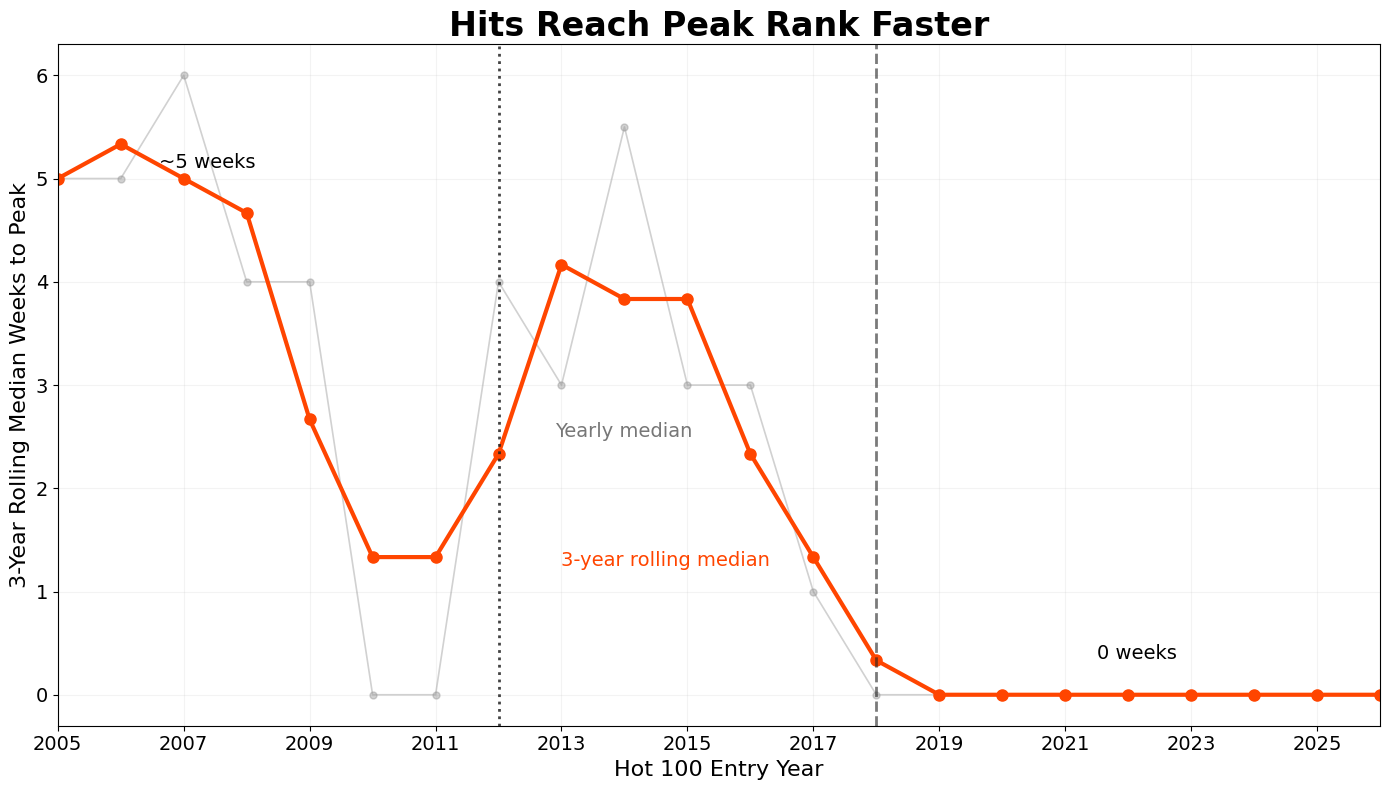

In [87]:
# ============================================================
# Billboard Time-to-Peak Trend (Final Poster Version)
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Yearly median time to peak for completed songs only
# ------------------------------------------------------------
median_time_to_peak_completed = (
    song_life_completed
    .groupby("entry_year")["time_to_peak"]
    .median()
)

# ------------------------------------------------------------
# 3-year rolling median
# ------------------------------------------------------------
median_time_to_peak_completed_roll = (
    median_time_to_peak_completed
    .rolling(
        window=3,
        center=True,
        min_periods=1
    )
    .mean()
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))

# Raw yearly median in background
ax.plot(
    median_time_to_peak_completed.index,
    median_time_to_peak_completed.values,
    marker="o",
    markersize=5,
    linewidth=1.2,
    color="#999999",
    alpha=0.45,
    label="Yearly median"
)

# Rolling median as main trend
ax.plot(
    median_time_to_peak_completed_roll.index,
    median_time_to_peak_completed_roll.values,
    marker="o",
    markersize=8,
    linewidth=3,
    color="#ff4500",
    label="3-year rolling median"
)

# ------------------------------------------------------------
# Era milestone lines
# ------------------------------------------------------------
ax.axvline(
    x=2012,
    linestyle=":",
    linewidth=2.0,
    color="#222222",
    alpha=0.85
)

ax.axvline(
    x=2018,
    linestyle="--",
    linewidth=2.0,
    color="#222222",
    alpha=0.60
)

# ------------------------------------------------------------
# Endpoint annotations
# ------------------------------------------------------------
ax.text(
    2006.6,
    5.1,
    "~5 weeks",
    fontsize=14
)

ax.text(
    2021.5,
    0.35,
    "0 weeks",
    fontsize=14
)

# ------------------------------------------------------------
# Labels and title
# ------------------------------------------------------------
ax.set_title(
    "Hits Reach Peak Rank Faster",
    fontsize=24,
    fontweight="bold"
)

ax.set_xlabel(
    "Hot 100 Entry Year",
    fontsize=16
)

ax.set_ylabel(
    "3-Year Rolling Median Weeks to Peak",
    fontsize=16
)

ax.set_xticks(range(2005, 2026, 2))
ax.set_xlim(2005, 2026)

ax.tick_params(
    axis="both",
    labelsize=14
)

# ------------------------------------------------------------
# Direct labels instead of legend
# ------------------------------------------------------------
ax.text(
    2013,
    1.25,
    "3-year rolling median",
    color="#ff4500",
    fontsize=14
)

ax.text(
    2012.9,
    2.5,
    "Yearly median",
    color="#777777",
    fontsize=14
)

# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------
ax.grid(
    True,
    alpha=0.15
)

fig.tight_layout()

# ------------------------------------------------------------
# Export
# ------------------------------------------------------------
filename = "billboard_time_to_peak_trend.png"

fig.savefig(
    filename,
    dpi=1200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [8]:
era_summary = (
    song_life_completed
    .groupby("era")
    .agg(
        songs=("Song", "count"),
        median_lifespan=("lifespan_weeks", "median"),
        mean_lifespan=("lifespan_weeks", "mean"),
        median_time_to_peak=("time_to_peak", "median"),
        mean_top10_weeks=("top10_weeks", "mean"),
        mean_top40_weeks=("top40_weeks", "mean"),
        percent_top10=("peak_rank", lambda x: (x <= 10).mean() * 100),
        median_peak_rank=("peak_rank", "median")
    )
    .round(2)
)

era_summary

,songs,median_lifespan,mean_lifespan,median_time_to_peak,mean_top10_weeks,mean_top40_weeks,percent_top10,median_peak_rank
era,,,,,,,,
Post TikTok,5030,2.0,8.17,0.0,0.75,3.11,9.48,53.0
Pre TikTok,5333,13.0,13.32,3.0,1.33,5.28,13.97,51.0


### Summary statistics table LOADED✅

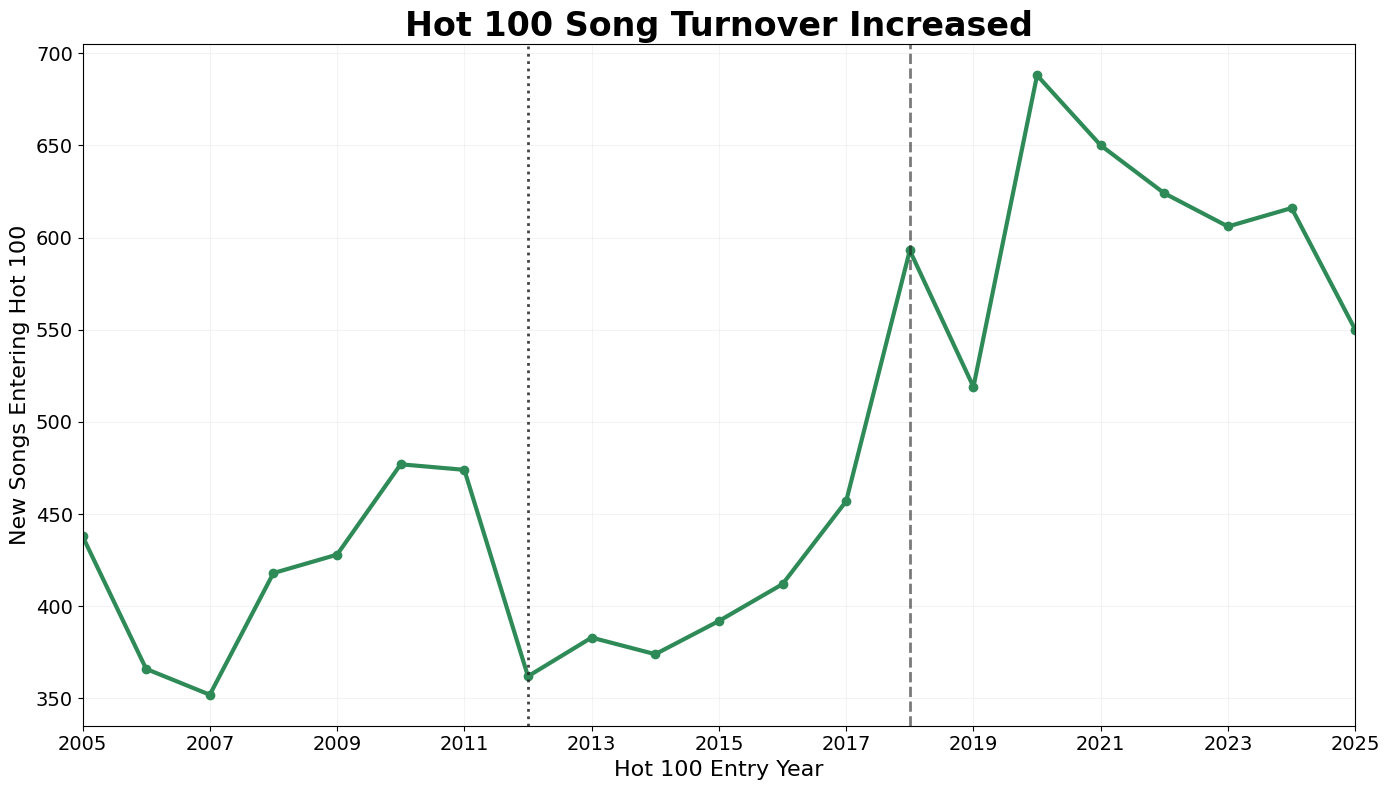

In [93]:
# ============================================================
# Hot 100 Song Turnover Trend (Final Poster Version)
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Count unique songs entering each year
# ------------------------------------------------------------
songs_per_year = (
    song_life_completed
    .groupby("entry_year")
    .size()
)

# Remove incomplete 2026
songs_per_year = songs_per_year.loc[
    songs_per_year.index <= 2025
]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(
    songs_per_year.index,
    songs_per_year.values,
    marker="o",
    linewidth=3,
    color="#2E8B57"
)
# ------------------------------------------------------------
# Era milestone lines
# ------------------------------------------------------------
ax.axvline(
    x=2012,
    linestyle=":",
    linewidth=2.0,
    color="#222222",
    alpha=0.85
)

ax.axvline(
    x=2018,
    linestyle="--",
    linewidth=2.0,
    color="#222222",
    alpha=0.60
)

# ------------------------------------------------------------
# Labels and title
# ------------------------------------------------------------
ax.set_title(
    "Hot 100 Song Turnover Increased",
    fontsize=24,
    fontweight="bold"
)

ax.set_xlabel(
    "Hot 100 Entry Year",
    fontsize=16
)

ax.set_ylabel(
    "New Songs Entering Hot 100",
    fontsize=16
)

ax.set_xticks(range(2005, 2026, 2))
ax.set_xlim(2005, 2025)

ax.tick_params(
    axis="both",
    labelsize=14
)

# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------
ax.grid(
    True,
    alpha=0.15
)

fig.tight_layout()

# ------------------------------------------------------------
# Export
# ------------------------------------------------------------
filename = "hot100_song_turnover_trend.png"

fig.savefig(
    filename,
    dpi=1200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [9]:
# -----------------------------
# 1. Make yearly song counts
# -----------------------------
songs_per_year = (
    song_life_completed
    .groupby("entry_year")
    .size()
    .reset_index(name="songs_per_year")
)

songs_per_year["era"] = np.where(
    songs_per_year["entry_year"] < 2018,
    "Pre TikTok",
    "Post TikTok"
)

# Average number of unique Hot 100 entries per year in each era
songs_per_year_summary = (
    songs_per_year
    .groupby("era")["songs_per_year"]
    .mean()
)

# -----------------------------
# 2. Make chart dynamics summary
# -----------------------------
summary_table = pd.DataFrame({
    "Metric": [
        "Median Lifespan (weeks)",
        "Median Time to Peak (weeks)",
        "% Reaching Top 10",
        "Avg. Songs Entering / Year"
    ],
    "Pre TikTok": [
        era_summary.loc["Pre TikTok", "median_lifespan"],
        era_summary.loc["Pre TikTok", "median_time_to_peak"],
        era_summary.loc["Pre TikTok", "percent_top10"],
        songs_per_year_summary.loc["Pre TikTok"]
    ],
    "Post TikTok": [
        era_summary.loc["Post TikTok", "median_lifespan"],
        era_summary.loc["Post TikTok", "median_time_to_peak"],
        era_summary.loc["Post TikTok", "percent_top10"],
        songs_per_year_summary.loc["Post TikTok"]
    ],
    "p-value": [
        "<0.001",
        "<0.001",
        "<0.001",
        "0.003"
    ]
})

# -----------------------------
# 3. Calculate percent change
# -----------------------------
summary_table["% Change"] = (
    (
        (summary_table["Post TikTok"] - summary_table["Pre TikTok"])
        / summary_table["Pre TikTok"]
    ) * 100
).round(1)

# Add + sign for increases
summary_table["% Change"] = summary_table["% Change"].apply(
    lambda x: f"+{x}%" if x > 0 else f"{x}%"
)

# -----------------------------
# 4. Round values for readability
# -----------------------------
summary_table["Pre TikTok"] = summary_table["Pre TikTok"].round(1)
summary_table["Post TikTok"] = summary_table["Post TikTok"].round(1)

summary_table = summary_table[
    [
        "Metric",
        "Pre TikTok",
        "Post TikTok",
        "% Change",
        "p-value"
    ]
]
display(summary_table)

# Optional export
# summary_table.to_csv("chart_dynamics_summary_table.csv", index=False)

,Metric,Pre TikTok,Post TikTok,% Change,p-value
0,Median Lifespan (weeks),13.0,2.0,-84.6%,<0.001
1,Median Time to Peak (weeks),3.0,0.0,-100.0%,<0.001
2,% Reaching Top 10,14.0,9.5,-32.1%,<0.001
3,Avg. Songs Entering / Year,410.2,558.9,+36.2%,0.003


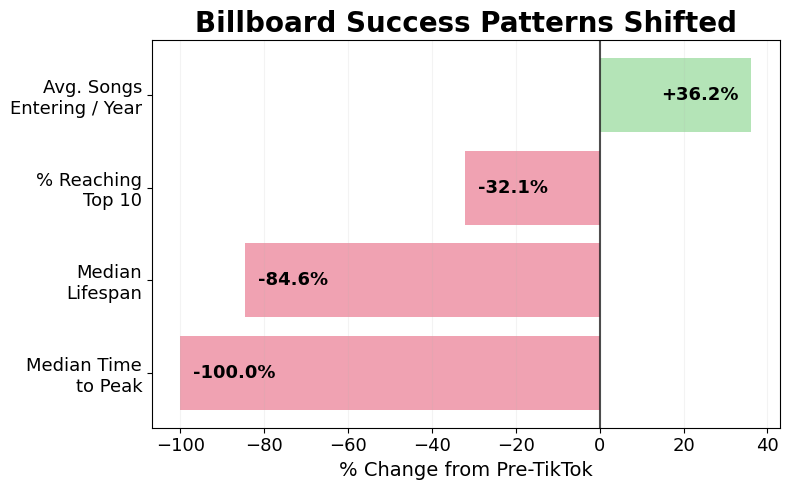

In [78]:
# ============================================================
# Billboard Success Patterns Shifted
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

billboard_change = pd.DataFrame({
    "Metric": [
        "Avg. Songs\nEntering / Year",
        "% Reaching\nTop 10",
        "Median\nLifespan",
        "Median Time\nto Peak"
    ],
    "% Change": [
        36.2,
        -32.1,
        -84.6,
        -100.0
    ]
})

billboard_change = billboard_change.sort_values("% Change")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

bar_colors = [
    "#ef98aa" if x < 0 else "#ace1af"
    for x in billboard_change["% Change"]
]

bars = ax.barh(
    billboard_change["Metric"],
    billboard_change["% Change"],
    color=bar_colors,
    alpha=0.90
)

# ------------------------------------------------------------
# Zero line
# ------------------------------------------------------------
ax.axvline(
    x=0,
    color="#222222",
    linewidth=1.5,
    alpha=0.80
)

# ------------------------------------------------------------
# Labels
# Match style of audio feature chart
# ------------------------------------------------------------
for i, value in enumerate(billboard_change["% Change"]):

    if value > 0:
        ax.text(
            value - 3,
            i,
            f"{value:+.1f}%",
            va="center",
            ha="right",
            fontsize=13,
            fontweight="bold"
        )

    else:
        ax.text(
            value + 3,
            i,
            f"{value:+.1f}%",
            va="center",
            ha="left",
            fontsize=13,
            fontweight="bold"
        )

# ------------------------------------------------------------
# Title and labels
# ------------------------------------------------------------
ax.set_title(
    "Billboard Success Patterns Shifted",
    fontsize=20,
    fontweight="bold"
)

ax.set_xlabel(
    "% Change from Pre-TikTok",
    fontsize=14
)

ax.tick_params(
    axis="both",
    labelsize=13
)

# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------
ax.grid(
    axis="x",
    alpha=0.15
)

fig.tight_layout()

# ------------------------------------------------------------
# Export
# ------------------------------------------------------------
filename = "billboard_metric_changes.png"

fig.savefig(
    filename,
    dpi=1200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# Audio Analysis

### Audio cluster Composition (stacked chart) LOADED✅

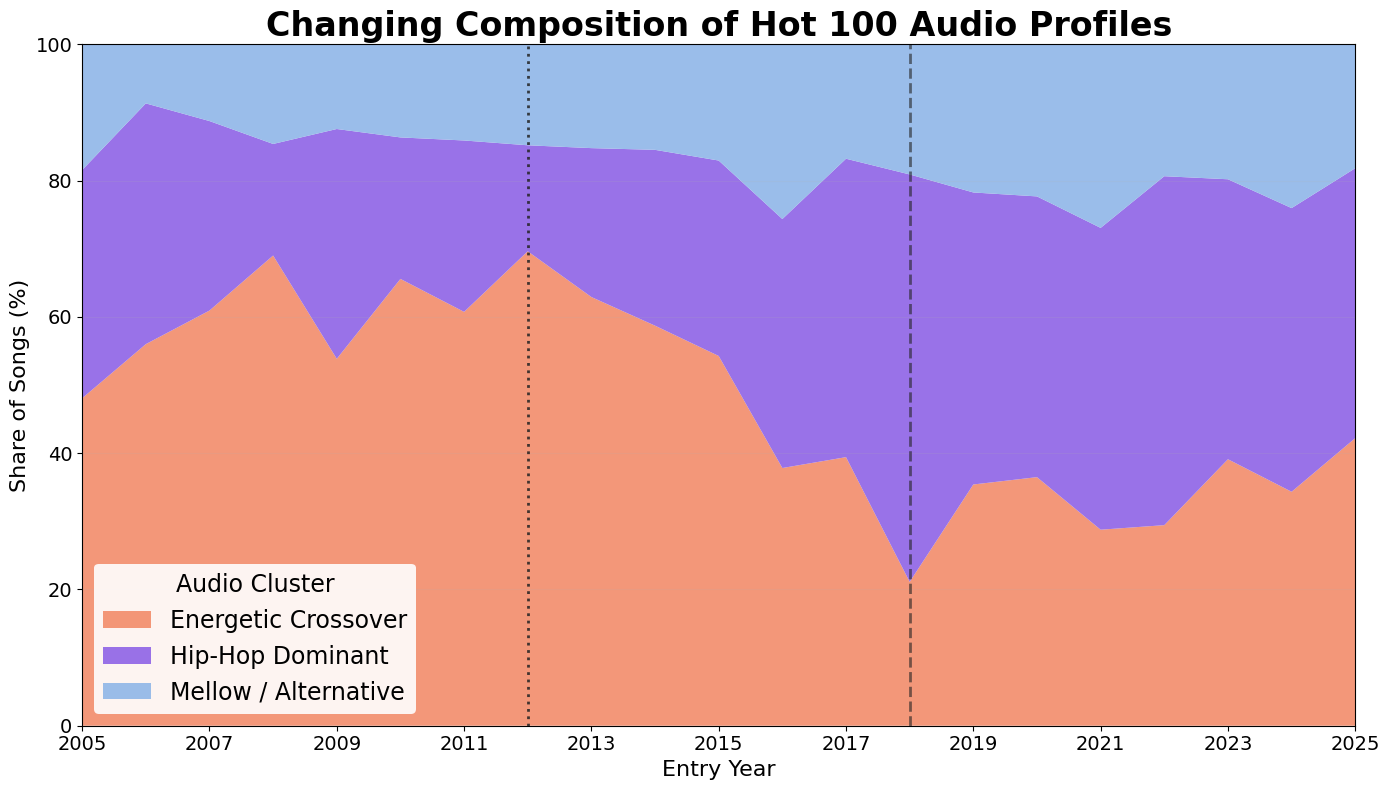

In [26]:
# ============================================================
# Audio Cluster Composition Over Time (Final Poster Version)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Abby's color palette
# ------------------------------------------------------------
cluster_colors = [
    "#F28C6A",  # Energetic Crossover - coral/salmon
    "#8E63E6",  # Hip-Hop Dominant - purple
    "#8FB6E8"   # Mellow / Alternative - light blue
]

# ------------------------------------------------------------
# Build yearly cluster composition
# ------------------------------------------------------------
cluster_pct_year = (
    pd.crosstab(
        audio_df["entry_year"],
        audio_df["audio_cluster"],
        normalize="index"
    ) * 100
)

cluster_pct_year = cluster_pct_year.rename(columns={
    0: "Energetic Crossover",
    1: "Hip-Hop Dominant",
    2: "Mellow / Alternative"
})

# Remove incomplete 2026 from timeline
cluster_pct_year = cluster_pct_year.loc[
    cluster_pct_year.index <= 2025
]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))

ax.stackplot(
    cluster_pct_year.index,
    cluster_pct_year["Energetic Crossover"],
    cluster_pct_year["Hip-Hop Dominant"],
    cluster_pct_year["Mellow / Alternative"],
    labels=cluster_pct_year.columns,
    colors=cluster_colors,
    alpha=0.90
)

# ------------------------------------------------------------
# Era milestone lines
# ------------------------------------------------------------
ax.axvline(
    x=2012,
    linestyle=":",
    linewidth=2.0,
    color="#222222",
    alpha=0.85
)

ax.axvline(
    x=2018,
    linestyle="--",
    linewidth=2.0,
    color="#222222",
    alpha=0.60
)

'''
# ------------------------------------------------------------
# Annotation boxes (removed because meh)
# ------------------------------------------------------------

box_style = dict(
    facecolor="white",
    edgecolor="none",
    boxstyle="round,pad=0.35",
    alpha=0.90
)

ax.text(
    2012.2,
    88,
    "Streaming added\nto Hot 100",
    fontsize=13,
    bbox=box_style
)

ax.text(
    2018.2,
    83,
    "TikTok era\nbegins",
    fontsize=13,
    bbox=box_style
)
'''

# ------------------------------------------------------------
# Labels and title
# ------------------------------------------------------------
ax.set_title(
    "Changing Composition of Hot 100 Audio Profiles",
    fontsize=24,
    fontweight="bold"
)

ax.set_xlabel("Entry Year", fontsize=16)
ax.set_ylabel("Share of Songs (%)", fontsize=16)

ax.set_xticks(range(2005, 2026, 2))
ax.set_xlim(2005, 2025)
ax.set_ylim(0, 100)

ax.tick_params(axis="both", labelsize=14)

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------
legend = ax.legend(
    title="Audio Cluster",
    loc="lower left",
    fontsize=17,
    title_fontsize=17,
    frameon=True,
    fancybox=True
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("none")
legend.get_frame().set_alpha(0.90)

# ------------------------------------------------------------
# Grid and export
# ------------------------------------------------------------
ax.grid(axis="y", alpha=0.15)

fig.tight_layout()

filename = "audio_cluster_composition_over_time.png"

fig.savefig(
    filename,
    dpi=1200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [32]:
pd.DataFrame(
    audio_pca.components_.T,
    columns=["PC1", "PC2"],
    index=audio_features
)

,PC1,PC2
valence,0.597454,-0.032665
arousal,0.545946,-0.031999
rms_loudness,0.139624,0.773329
spectral_centroid_mean,0.520974,0.139098
tempo_bpm_adjusted,0.232556,-0.616866


In [35]:
loadings = pd.DataFrame(
    audio_pca.components_.T,
    columns=["PC1", "PC2"],
    index=audio_features
)

display(loadings.round(3))

,PC1,PC2
valence,0.597,-0.033
arousal,0.546,-0.032
rms_loudness,0.140,0.773
spectral_centroid_mean,0.521,0.139
tempo_bpm_adjusted,0.233,-0.617


In [33]:
print(audio_pca.explained_variance_ratio_)
print("Total:", audio_pca.explained_variance_ratio_.sum())

[0.42431507 0.20190709]
Total: 0.6262221555859305


In [36]:
for pc in ["PC1", "PC2"]:
    print(f"\n{pc}")
    print(loadings[pc].abs().sort_values(ascending=False))


PC1
valence                   0.597454
arousal                   0.545946
spectral_centroid_mean    0.520974
tempo_bpm_adjusted        0.232556
rms_loudness              0.139624
Name: PC1, dtype: float64

PC2
rms_loudness              0.773329
tempo_bpm_adjusted        0.616866
spectral_centroid_mean    0.139098
valence                   0.032665
arousal                   0.031999
Name: PC2, dtype: float64


### Audio Feature Summary Table LOADED✅

In [11]:
# Audio features to compare across eras
feature_cols = [
    "valence",
    "arousal",
    "rms_loudness",
    "spectral_centroid_mean",
    "tempo_bpm_adjusted"
]

# Calculate era means
feature_summary = (
    audio_df
    .groupby("audio_era")[feature_cols]
    .mean()
    .T
)

# Force order
feature_summary = feature_summary[["Pre TikTok", "Post TikTok"]]

# Calculate percent change
feature_summary["% Change"] = (
    (feature_summary["Post TikTok"] - feature_summary["Pre TikTok"])
    / feature_summary["Pre TikTok"]
    * 100
).round(1)

# Run Mann-Whitney tests for each feature
p_values = []

for feature in feature_cols:
    pre = audio_df.loc[audio_df["audio_era"] == "Pre TikTok", feature].dropna()
    post = audio_df.loc[audio_df["audio_era"] == "Post TikTok", feature].dropna()

    u, p = mannwhitneyu(pre, post, alternative="two-sided")
    p_values.append(p)

feature_summary["p-value"] = p_values

# Clean feature names for display
feature_summary = feature_summary.rename(index={
    "valence": "Valence",
    "arousal": "Arousal",
    "rms_loudness": "Loudness",
    "spectral_centroid_mean": "Brightness",
    "tempo_bpm_adjusted": "Tempo"
})

display(feature_summary.round(3))

audio_era,Pre TikTok,Post TikTok,% Change,p-value
Valence,5.756,5.293,-8.0,0.000
Arousal,5.483,5.331,-2.8,0.000
Loudness,0.277,0.296,7.1,0.000
Brightness,3244.572,2857.029,-11.9,0.000
Tempo,110.048,107.481,-2.3,0.001


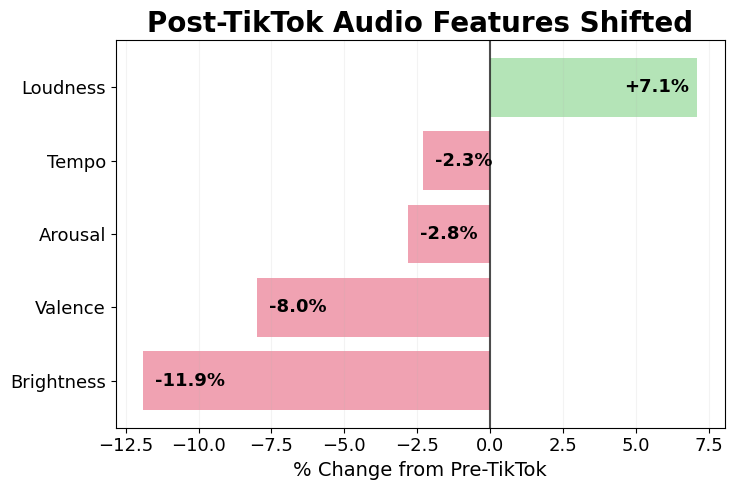

In [79]:
# ============================================================
# Audio Feature Percent Change Bar Chart
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

feature_change = pd.DataFrame({
    "Feature": ["Valence", "Arousal", "Loudness", "Brightness", "Tempo"],
    "% Change": [-8.0, -2.8, 7.1, -11.9, -2.3]
})

feature_change = feature_change.sort_values("% Change")

fig, ax = plt.subplots(figsize=(8, 5))

bar_colors = [
    "#ef98aa" if x < 0 else "#ace1af"
    for x in feature_change["% Change"]
]

ax.barh(
    feature_change["Feature"],
    feature_change["% Change"],
    color=bar_colors,
    alpha=0.9
)

ax.axvline(
    x=0,
    color="#222222",
    linewidth=1.5,
    alpha=0.8
)

for i, value in enumerate(feature_change["% Change"]):

    if value >= 0:
        x = value - 2.5
        ha = "left"
    else:
        x = value + 0.4   # place inside the bar instead
        ha = "left"

    ax.text(
        x,
        i,
        f"{value:+.1f}%",
        va="center",
        ha=ha,
        fontsize=13,
        fontweight="bold"
    )

ax.set_title(
    "Post-TikTok Audio Features Shifted",
    fontsize=20,
    fontweight="bold"
)

ax.set_xlabel("% Change from Pre-TikTok", fontsize=14)
ax.tick_params(axis="both", labelsize=13)

ax.grid(axis="x", alpha=0.15)

fig.tight_layout()

fig.tight_layout()
plt.subplots_adjust(left=0.22)

filename = "audio_feature_percent_change.png"

fig.savefig(
    filename,
    dpi=1200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### PCA 3-Cluster Visualization LOADED✅

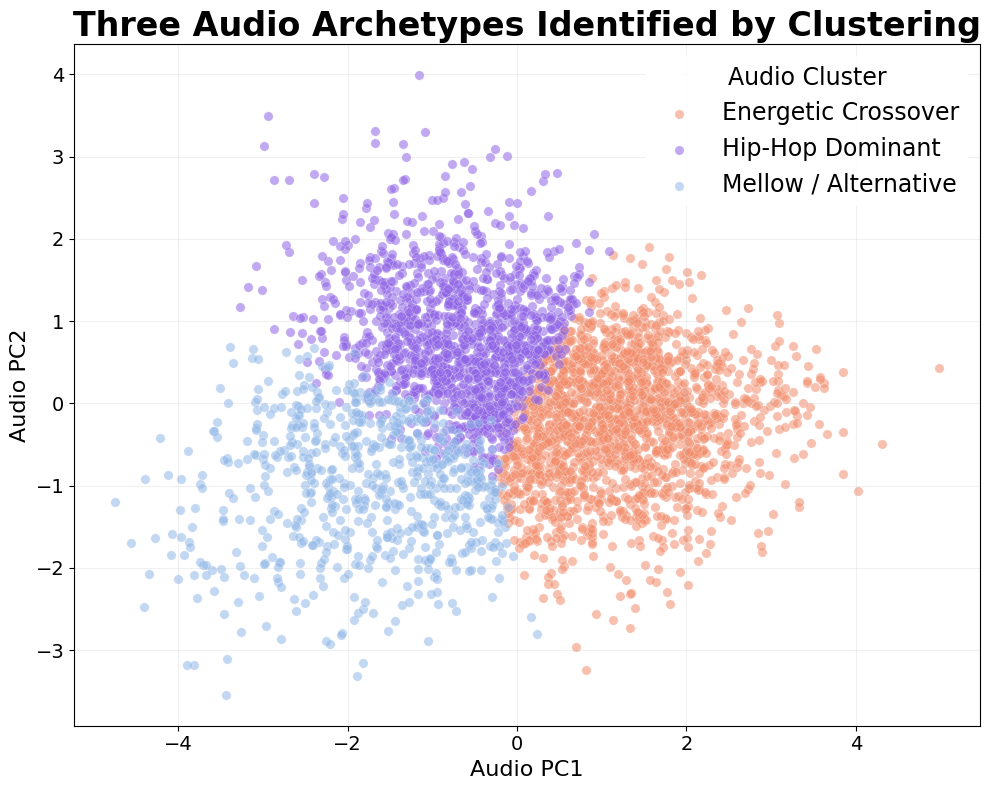

In [57]:
# ============================================================
# PCA Audio Feature Clusters (Final Poster Version)
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Same colors as stacked area chart
# ------------------------------------------------------------
cluster_colors = {
    0: "#F28C6A",  # Energetic Crossover
    1: "#8E63E6",  # Hip-Hop Dominant
    2: "#8FB6E8"   # Mellow / Alternative
}

cluster_labels = {
    0: "Energetic Crossover",
    1: "Hip-Hop Dominant",
    2: "Mellow / Alternative"
}

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))

for cluster in sorted(audio_df["audio_cluster"].unique()):
    subset = audio_df[audio_df["audio_cluster"] == cluster]

    ax.scatter(
        subset["audio_PC1"],
        subset["audio_PC2"],
        color=cluster_colors[cluster],
        alpha=0.55,
        s=45,
        edgecolor="white",
        linewidth=0.3,
        label=cluster_labels[cluster]
    )

# ------------------------------------------------------------
# Labels and title
# ------------------------------------------------------------
ax.set_title(
    "Three Audio Archetypes Identified by Clustering",
    fontsize=24,
    fontweight="bold"
)

ax.set_xlabel("Audio PC1", fontsize=16)
ax.set_ylabel("Audio PC2", fontsize=16)

ax.tick_params(axis="both", labelsize=14)

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------
legend = ax.legend(
    title="Audio Cluster",
    loc="upper right",
    fontsize=17,
    title_fontsize=17,
    frameon=True,
    fancybox=True
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("none")
legend.get_frame().set_alpha(0.90)

# ------------------------------------------------------------
# Grid and export
# ------------------------------------------------------------
ax.grid(True, alpha=0.18)

fig.tight_layout()

filename = "audio_feature_clusters_pca.png"

fig.savefig(
    filename,
    dpi=1200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

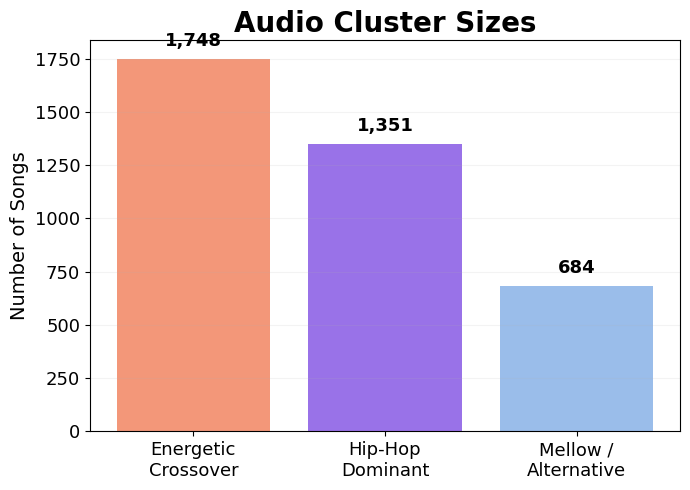

In [70]:
# ============================================================
# Audio Cluster Size Distribution
# ============================================================

import matplotlib.pyplot as plt

cluster_labels = {
    0: "Energetic\nCrossover",
    1: "Hip-Hop\nDominant",
    2: "Mellow /\nAlternative"
}

cluster_colors = {
    0: "#F28C6A",
    1: "#8E63E6",
    2: "#8FB6E8"
}

cluster_counts = (
    audio_df["audio_cluster"]
    .value_counts()
    .sort_index()
)

labels = [cluster_labels[i] for i in cluster_counts.index]
colors = [cluster_colors[i] for i in cluster_counts.index]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    labels,
    cluster_counts.values,
    color=colors,
    alpha=0.9
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 40,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold"
    )

ax.set_title(
    "Audio Cluster Sizes",
    fontsize=20,
    fontweight="bold"
)

ax.set_ylabel("Number of Songs", fontsize=14)
ax.tick_params(axis="both", labelsize=13)

ax.grid(axis="y", alpha=0.15)

fig.tight_layout()

filename = "audio_cluster_size_distribution.png"

fig.savefig(
    filename,
    dpi=1200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### Cluster Profile Table (removed; won't include probably)

In [13]:
audio_df.groupby("audio_cluster")[
    [
        "valence",
        "arousal",
        "rms_loudness",
        "spectral_centroid_mean",
        "tempo_bpm_adjusted"
    ]
].mean().round(2)

,valence,arousal,rms_loudness,spectral_centroid_mean,tempo_bpm_adjusted
audio_cluster,,,,,
0,6.24,5.83,0.28,3496.32,118.42
1,5.06,5.18,0.33,2893.34,96.34
2,4.74,4.80,0.20,2316.46,109.24


In [95]:
print(audio_df.shape)

(3783, 90)


In [96]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

audio_cluster_features = [
    "valence",
    "arousal",
    "rms_loudness",
    "spectral_centroid_mean",
    "spectral_rolloff_mean",
    "tempo_bpm",
    "beat_confidence"
]

X = audio_df[audio_cluster_features]
X_scaled = StandardScaler().fit_transform(X)

cluster_validation = []

for k in range(2, 9):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    labels = km.fit_predict(X_scaled)
    
    cluster_validation.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_scaled, labels)
    })

cluster_validation_df = pd.DataFrame(cluster_validation)

display(cluster_validation_df.round(3))

,k,inertia,silhouette
0,2,19656.402,0.225
1,3,17361.291,0.191
2,4,15641.339,0.180
3,5,14280.708,0.160
4,6,13247.063,0.159
5,7,12509.920,0.161
6,8,11997.376,0.153


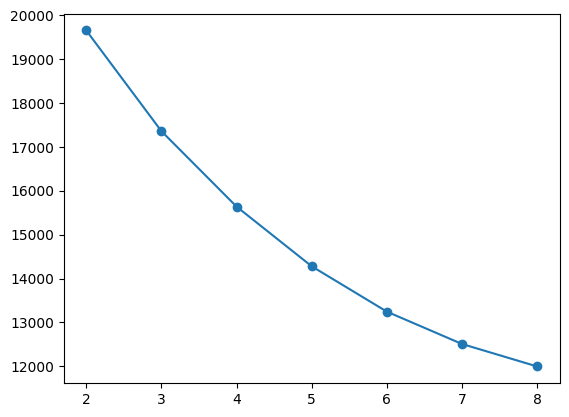

In [97]:
plt.plot(cluster_validation_df["k"],
         cluster_validation_df["inertia"],
         marker="o")

In [98]:
for k in [2,3,4]:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = km.fit_predict(X_scaled)

    print("\nK =", k)
    print(pd.Series(labels).value_counts().sort_index())


K = 2
0    1970
1    1813
Name: count, dtype: int64

K = 3
0    1459
1    1752
2     572
Name: count, dtype: int64

K = 4
0     455
1     906
2    1071
3    1351
Name: count, dtype: int64
